# 00 - Install And Setup

Welcome. This notebook is a quick first check that eCAT is available in your notebook kernel and that the packaged example data can be loaded, inspected, and plotted.

The example files are small CH Instruments text exports included with the repository, so everything here should run without private lab paths. Once this works, the same pattern can be reused with your own data folder by changing `DATA_DIR`.

## Import eCAT And Locate Example Data

Start by importing eCAT from this checkout and pointing the notebook at the packaged Fe/PhOH CV example folder. The setup cell also creates a local `_outputs` folder for figures you may choose to save later.

In [ ]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent


def display_path(path):
    path = Path(path)
    try:
        return str(path.resolve().relative_to(ROOT.resolve()))
    except ValueError:
        return path.name

if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import ecat as e

DATA_DIR = ROOT / "examples" / "data" / "fe_phoh_cv"
EXPORT_DIR = ROOT / "notebooks" / "_outputs"
EXPORT_DIR.mkdir(exist_ok=True)

e.plotting_style("notebook")
print("eCAT version:", getattr(e, "__version__", "unknown"))
print("Example data:", display_path(DATA_DIR))
print("Text files:", len(list(DATA_DIR.glob("*.txt"))))

eCAT version: 0.1.0b2
Example data: examples/data/fe_phoh_cv
Text files: 13


## Discover Common Entry Points

`describe_options()` is the built-in menu for eCAT options. Calling it without a section shows the available option sections; later notebooks use section names like `plot`, `get_data`, and `multiplot`.

In [ ]:
print("Common starting points:")
print("- e.echem.from_file(path)")
print("- e.get_data({'folder path': path})")
print("- e.describe_options('plot')")

menu = e.describe_options(None, {"print": False, "return": True});
menu.head(10)

Common starting points:
- e.echem.from_file(path)
- e.get_data({'folder path': path})
- e.describe_options('plot')


,Function,Description
0,all,Show options for every function.
1,ca.charge,"Show options for ""ca.charge""."
2,ca.plot,"Show options for ""ca.plot""."
3,ca.time_at_charge,"Show options for ""ca.time_at_charge""."
4,cp.cycle_info,"Show options for ""cp.cycle_info""."
5,cp.cycling_plot,"Show options for ""cp.cycling_plot""."
6,cp.get_cycles,"Show options for ""cp.get_cycles""."
7,cp.plot,"Show options for ""cp.plot""."
8,cp.plot_cycles,"Show options for ""cp.plot_cycles""."
9,cv.current_at_potential,"Show options for ""cv.current_at_potential""."


Python's built-in `help()` is useful too. It shows the docstring for a function, including a short description and example call.

In [ ]:
help(e.get_data)

Help on function get_data in module ecat.io:

get_data(options={})
    Read electrochemistry text files from a folder into eCAT objects.

    Parameters
    ----------
    options : dict or ImportOptions, optional
        Import, parsing, sorting, and reference-shift options. See ``e.describe_options("get_data")``.

    Returns
    -------
    list of echem
        Imported CV, DPV, CA, CP, CPE, or generic electrochemistry objects.

    Examples
    --------
    >>> cvs = e.get_data({"folder path": folder, "reference mode": "keyword"})



## Load One CV With `from_file`

Use `e.echem.from_file()` when you want to inspect one text export before loading a whole folder. The returned object is saved as `cv`, and `e.show(cv)` gives a tidy Info + Stats table before any `get_data()` folder import happens.

In [ ]:
first_file = DATA_DIR / "MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_to_1V_100mVs.txt"
cv = e.echem.from_file(str(first_file))

e.show(cv);

,Metric,Value
0,Name,MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_to_1V_100mVs
1,Timestamp,2026-05-07 14:42:19
2,Creation Time,2026-06-08 12:16:55.081368
3,Modification Time,2026-06-08 12:16:55.082093
4,IR Comp Resistance,132 ohm
5,IR Uncomp Resistance,0 ohm
6,IR Comp Percent,100 %
7,Solvent,MeCN
8,Gas,Ar
9,Compounds,"TBAPF6, Fc, Fe-tpyPY2Me"


## Load A Folder With `get_data`

Use `get_data()` when you want eCAT to read every supported text export in a folder. This returns a list of eCAT objects, one per file.

In [ ]:
cvs = e.get_data({
    "folder path": str(DATA_DIR),
    "reference mode": "none",
    "print": False,
})
cvs = e.filter(cvs, {"segments": 3}, {"print": False})
print(f"Loaded {len(cvs)} CV objects")
print(sorted({type(obj).__name__ for obj in cvs}))

Searching recursively through:
 examples/data/fe_phoh_cv
13 .txt files found.

Loaded 12 CV objects
['cv']


## Inspect Loaded Objects With `show_objects`

`show_objects()` gives a compact table for a list of objects. It is often the fastest way to confirm names, gases, scan rates, and compounds before filtering or plotting.

In [ ]:
e.show_objects(cvs);

[Conditions] Exp Type: CV, Solvent: MeCN, Compounds: 0.1 M TBAPF₆, Segments: 3, IR Comp Percent: 100 %


,Gas,Compounds,Scan Window,Scan Rate
[0],Ar,,"[-1.2, 1]",100 mV/s
[1],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.2, 1]",100 mV/s
[2],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",100 mV/s
[3],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",25 mV/s
[4],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",500 mV/s
[5],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",1 V/s
[6],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",50 mV/s
[7],CO2,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.2, 1]",100 mV/s
[8],CO2,"3 mM Fc, 1 mM Fe-tpyPY2Me, 100 mM PhOH","[-1.2, 1]",100 mV/s
[9],CO2,"3 mM Fc, 1 mM Fe-tpyPY2Me, 560 mM PhOH","[-1.2, 1]",100 mV/s


## Plot The Single CV

Calling `.plot()` on an eCAT object draws the selected CV. The commented line shows the usual way to save the figure after you like how it looks.

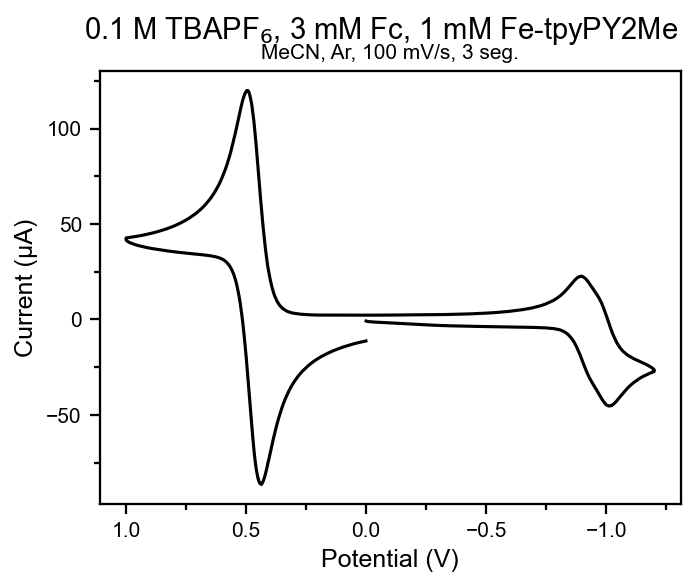

In [ ]:
ax = cv.plot()
# ax.figure.savefig(EXPORT_DIR / "first_cv.svg", dpi=300, bbox_inches="tight")